<a href="https://colab.research.google.com/github/thisara852/Machine-Learning-1/blob/main/Wcss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
#data = {"CustomerID":[1,2,3,4,5,6,7,8,9,10],
#"Age":[22,25,24,45,50,48,30,32,29,31],
#"MonthlySpend":[15,20,18,80,85,78,40,42,38,45] }
#df = pd.DataFrame(data)
df=pd.read_csv("/content/customer_spending_dataset.csv")
print(df)

   CustomerID  Age  MonthlySpend
0           1   22            15
1           2   25            20
2           3   24            18
3           4   45            80
4           5   50            85
5           6   48            78
6           7   30            40
7           8   32            42
8           9   29            38
9          10   31            45


In [2]:
X = df[["Age","MonthlySpend"]]

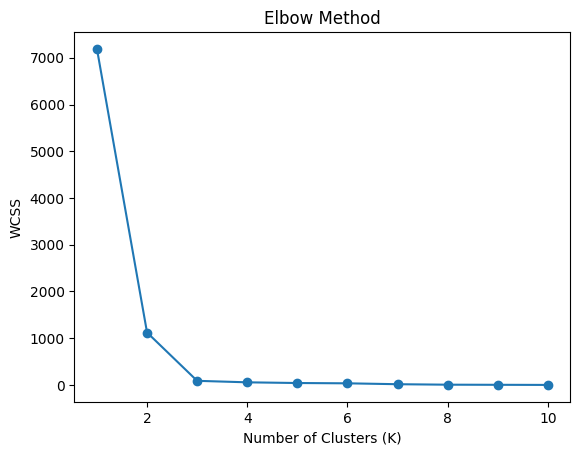

In [3]:
wcss = []

for k in range(1,11):
  model = KMeans(n_clusters=k, random_state=42)
  model.fit(X)
  wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [4]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = model.fit_predict(X)
print(df)

   CustomerID  Age  MonthlySpend  Cluster
0           1   22            15        2
1           2   25            20        2
2           3   24            18        2
3           4   45            80        0
4           5   50            85        0
5           6   48            78        0
6           7   30            40        1
7           8   32            42        1
8           9   29            38        1
9          10   31            45        1


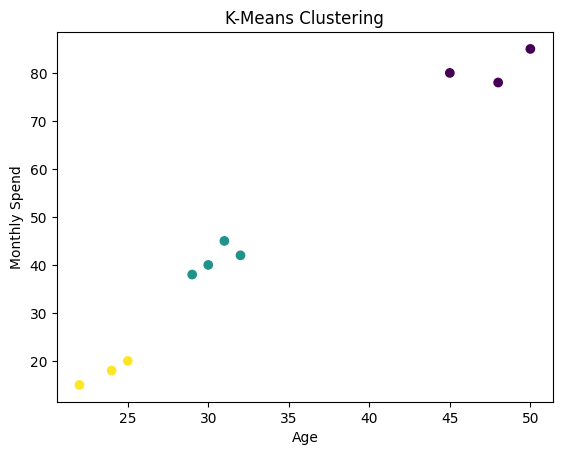

In [5]:
plt.scatter(df["Age"], df["MonthlySpend"],
c=df["Cluster"], cmap="viridis")
plt.xlabel("Age")
plt.ylabel("Monthly Spend")
plt.title("K-Means Clustering")
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df["Cluster"])

print("Silhouette Score =", score)

Silhouette Score = 0.8410625088244515
